# K-Means Clustering of Chicken Calls By Acoustic Features
K-Means clustering is an unsupervised machine learning technique to cluster cases into groups by their features. It's a method of partitional clustering, where every case must fit in one and only one group. In this project, individual chicken calls were clustered by the numerical features extracted from the audio. 

For this analysis, only adult chicken calls were included.

Steps
1. Import and visualize data using a scatterplot
2. Drop metadata columns
3. Use StandardScaler to get all variables on the same scale
4. Use principal components analysis (PCA) to reduce the number of variables
4. Use Elbow method to determine best number of clusters
5. Use K-means clustering to fit cases into clusters and append to original data
6. Explore characterstics of the clusters and plot using a scatterplot
7. Export results

Author: K Rubio

Last modified: 31Jul26

Dataset Information

Data created by using voice activity detection (VAD) to separate out individual calls from larger recordings, then for each call, audio features were extracted including zero-crossing rate, MFCCs 0-9, spectral centroid and bandwidth, etc. Program: chicken_feature_extraction_semi_automated.ipynb

1095 rows (one row per individual chicken call of varying durations)

Dataset columns include:
metadata
1.	filename
2.	call_num
3.	start
4.	end
5.	sample_rate
6.	frame_length
7.	vad_energy_threshold_used
8.  age (0 = chick, 1 = adult)

audio features
1.	duration_ms
2.	time_to_next_call_ms
3.	min_freq
4.	max_freq
5.	max_energy_freq
6.	seg1_max_energy_freq
7.	seg2_max_energy_freq
8.	seg3_max_energy_freq
9.	freq_change
10.	slope
11.	zcr
12.	mfcc0_avg
13.	mfcc0_std
14.	mfcc0_min
15.	mfcc0_max
16.	mfcc1_avg
17.	mfcc1_std
18.	mfcc1_min
19.	mfcc1_max
20.	mfcc2_avg
21.	mfcc2_std
22.	mfcc2_min
23.	mfcc2_max
24.	mfcc3_avg
25.	mfcc3_std
26.	mfcc3_min
27.	mfcc3_max
28.	mfcc4_avg
29.	mfcc4_std
30.	mfcc4_min
31.	mfcc4_max
32.	mfcc5_avg
33.	mfcc5_std
34.	mfcc5_min
35.	mfcc5_max
36.	mfcc6_avg
37.	mfcc6_std
38.	mfcc6_min
39.	mfcc6_max
40.	mfcc7_avg
41.	mfcc7_std
42.	mfcc7_min
43.	mfcc7_max
44.	mfcc8_avg
45.	mfcc8_std
46.	mfcc8_min
47.	mfcc8_max
48.	mfcc9_avg
49.	mfcc9_std
50.	mfcc9_min
51.	mfcc9_max	
52.	spectral_centroid
53.	spectral_bandwidth


In [1]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from scipy.stats import zscore
import seaborn as sns
from sklearn.model_selection import train_test_split
import os
import sys
from pathlib import Path
from datetime import date

In [2]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/ML_and_Data_Science/Audio Signal Processing/Completed Projects/2026_04_Audio_Signal_Analysis/audio-signal-analysis']


In [58]:
from utils.stats_utils import (
  print_mean_and_std_by_group
)

## Data Preparation

In [22]:
# import the data
filename = "chicken_call_audio_features_ready_for_clustering"
df = pd.read_csv(f"../../data/output/chickens/{filename}.csv")
df = df[df['age'] == 1]
df

,filename,age,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,...,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used
0,chickens_20250925_disturbed_at_nest_box2.wav,1,1,0.386,0.508,122,36.0,1205.859375,1421.191406,1335.058594,...,-14.538152,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786,22050,512,0.001
1,chickens_20250925_disturbed_at_nest_box2.wav,1,2,0.544,1.244,700,302.0,1033.593750,1378.125000,1119.726563,...,2.774709,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799,22050,512,0.001
2,chickens_20250925_disturbed_at_nest_box2.wav,1,3,1.546,2.146,600,416.0,1076.660156,1248.925781,1119.726563,...,-13.332011,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724,22050,512,0.001
3,chickens_20250925_disturbed_at_nest_box2.wav,1,4,2.562,3.046,484,354.0,689.062500,1076.660156,1033.593750,...,25.669295,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802,22050,512,0.001
4,chickens_20250925_disturbed_at_nest_box2.wav,1,5,3.400,3.930,530,NaN,1033.593750,1335.058594,1119.726563,...,10.740865,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258,22050,512,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,chickens_20201025_murmurs.wav,1,2,1.078,1.200,122,122.0,172.265625,1076.660156,215.332031,...,10.484846,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274,22050,512,0.005
1090,chickens_20201025_murmurs.wav,1,3,1.322,1.658,336,NaN,129.199219,1076.660156,387.597656,...,-1.260312,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987,22050,512,0.005
1091,chickens_20241006_0600_coop_low_growl.wav,1,1,1.582,1.724,142,38.0,129.199219,818.261719,258.398438,...,6.496047,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015,22050,512,0.005
1092,chickens_20241006_0600_coop_low_growl.wav,1,2,1.762,2.266,504,26.0,172.265625,645.996094,258.398438,...,5.026454,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427,22050,512,0.005


In [23]:
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 125


In [24]:
# Handle missing data in the "time_to_next_call" variable by replacing it with the mean from all rows
# that have the same filename
df["time_to_next_call_ms"] = (
    df["time_to_next_call_ms"]
      .fillna(
          df.groupby("filename")["time_to_next_call_ms"]
            .transform("mean")
      )
)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 17


In [25]:
# Since some calls were alone in their file, replace with overall mean
mean = df["time_to_next_call_ms"].mean()
df.fillna({"time_to_next_call_ms": mean}, inplace=True)
print(f"Number of missing values in time_to_next_call: {df['time_to_next_call_ms'].isna().sum()}")

Number of missing values in time_to_next_call: 0


In [26]:
cols_to_drop = ['filename', 'age', 'call_num', 'start', 'end', 'sample_rate', 'frame_length', 'vad_energy_threshold_used']
df2 = df.drop(cols_to_drop, axis=1, inplace=False)
df2

,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,seg1_max_energy_freq,seg2_max_energy_freq,seg3_max_energy_freq,freq_change,slope,...,mfcc8_avg,mfcc8_std,mfcc8_min,mfcc8_max,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth
0,122,36.000000,1205.859375,1421.191406,1335.058594,1335.058594,1291.992188,1378.125000,86.132812,353.003330,...,-36.094513,10.665915,-53.730093,-14.538152,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786
1,700,302.000000,1033.593750,1378.125000,1119.726563,1291.992188,1291.992188,1076.660156,215.332031,-307.617188,...,-34.062546,13.940853,-65.177905,2.774709,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799
2,600,416.000000,1076.660156,1248.925781,1119.726563,1119.726563,1119.726563,1119.726563,0.000000,0.000000,...,-38.068981,12.055237,-67.606766,-13.332011,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724
3,484,354.000000,689.062500,1076.660156,1033.593750,1033.593750,990.527344,732.128906,301.464844,-622.861247,...,-2.742786,14.347669,-33.636340,25.669295,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802
4,530,222.222222,1033.593750,1335.058594,1119.726563,1119.726563,1076.660156,1119.726563,43.066406,0.000000,...,-14.716567,14.359764,-58.971959,10.740865,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,122,122.000000,172.265625,1076.660156,215.332031,215.332031,215.332031,215.332031,0.000000,0.000000,...,-9.554047,7.066249,-19.091608,10.484846,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274
1090,336,90.000000,129.199219,1076.660156,387.597656,344.531250,387.597656,473.730469,129.199219,384.521484,...,-17.432987,6.289781,-27.487254,-1.260312,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987
1091,142,38.000000,129.199219,818.261719,258.398438,215.332031,258.398438,258.398438,43.066406,303.284551,...,-6.936776,6.410327,-20.430043,6.496047,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015
1092,504,26.000000,172.265625,645.996094,258.398438,258.398438,258.398438,258.398438,0.000000,0.000000,...,-16.382412,8.460439,-40.154185,5.026454,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427


In [27]:
scaler = StandardScaler()
X = scaler.fit_transform(df2)
X

array([[-0.31384101, -0.39410997,  3.33351403, ..., -1.28942599,
         2.63640995,  2.29862804],
       [ 1.76275554,  0.02902964,  2.60378513, ...,  1.28099345,
         0.48589829, -0.27065302],
       [ 1.40348278,  0.21037519,  2.78621735, ..., -0.62490816,
         0.1785311 , -0.97024211],
       ...,
       [-0.24198645, -0.39092847, -1.22729161, ...,  0.22772208,
         0.69275216,  2.40407809],
       [ 1.05858093, -0.41001747, -1.04485939, ..., -0.19039467,
         0.47154495,  2.31821394],
       [ 0.0382463 , -0.40047297, -1.04485939, ..., -0.33918764,
        -0.16025108,  1.85311987]])

## Principal Component Analysis

In [28]:
# Fit PCA without specifying the number of components, since this is unknown
pca = PCA()
X_pca = pca.fit_transform(X)

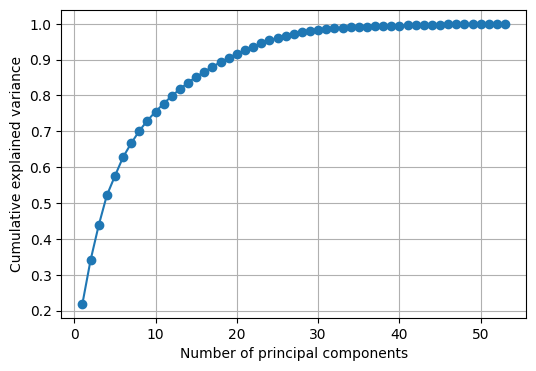

In [29]:
# Visualize how many components are needed to explain a certain % of variance in the dataset
plt.figure(figsize=(6,4))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_.cumsum(),
    marker="o"
)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

In [30]:
# Keep enough components to explain about 90% of the variance. Should be around 20 based on the graph above
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X)
print(pca.n_components_)

19


This means original 53 features were compressed into 19 principal components

## K-Means Clustering

<Axes: >

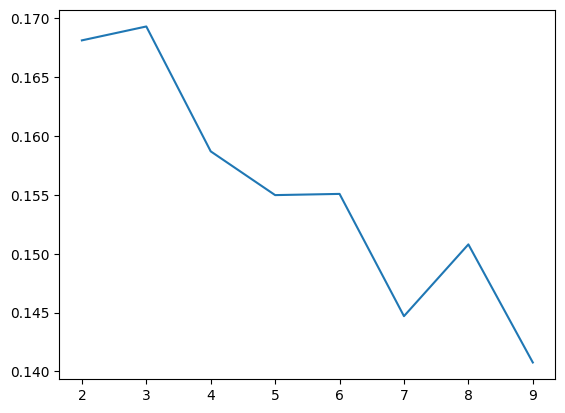

In [31]:
# Elbow method to determine best number of clusters
K = range(2, 10)
fits = []
score = []

for k in K:
    model = KMeans(n_clusters = k, random_state = 0, n_init='auto').fit(X_pca)
    fits.append(model)
    # Append the silhouette score to scores
    score.append(silhouette_score(X_pca, model.labels_, metric='euclidean'))
sns.lineplot(x = K, y = score)

Based on this graph, some good options include 7 or 9 clusters. Will go with 7

In [32]:
k = 8 # number of groups
kmeans = KMeans(n_clusters=k, random_state=0) # initialize kmeans algorithm
labels = kmeans.fit_predict(X_pca) # fit and predict to generate labels
df['cluster'] = labels # append those labels to the original df
df

,filename,age,call_num,start,end,duration_ms,time_to_next_call_ms,min_freq,max_freq,max_energy_freq,...,mfcc9_avg,mfcc9_std,mfcc9_min,mfcc9_max,spectral_centroid,spectral_bandwidth,sample_rate,frame_length,vad_energy_threshold_used,cluster
0,chickens_20250925_disturbed_at_nest_box2.wav,1,1,0.386,0.508,122,36.000000,1205.859375,1421.191406,1335.058594,...,-18.597576,6.832009,-33.007959,-9.699238,2905.300460,2624.356786,22050,512,0.001,1
1,chickens_20250925_disturbed_at_nest_box2.wav,1,2,0.544,1.244,700,302.000000,1033.593750,1378.125000,1119.726563,...,-23.577801,18.308346,-60.801953,26.842424,1871.231320,1644.881799,22050,512,0.001,2
2,chickens_20250925_disturbed_at_nest_box2.wav,1,3,1.546,2.146,600,416.000000,1076.660156,1248.925781,1119.726563,...,-28.341134,15.835605,-60.057400,-0.252303,1723.434437,1378.180724,22050,512,0.001,2
3,chickens_20250925_disturbed_at_nest_box2.wav,1,4,2.562,3.046,484,354.000000,689.062500,1076.660156,1033.593750,...,-14.385332,20.285077,-48.250835,16.092685,1400.304624,1286.143802,22050,512,0.001,2
4,chickens_20250925_disturbed_at_nest_box2.wav,1,5,3.400,3.930,530,222.222222,1033.593750,1335.058594,1119.726563,...,-9.885018,12.432922,-48.367343,19.022781,1801.598218,1627.250258,22050,512,0.001,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,chickens_20201025_murmurs.wav,1,2,1.078,1.200,122,122.000000,172.265625,1076.660156,215.332031,...,-9.869200,6.042165,-22.127784,4.626768,1653.708501,2150.898274,22050,512,0.005,7
1090,chickens_20201025_murmurs.wav,1,3,1.322,1.658,336,90.000000,129.199219,1076.660156,387.597656,...,-18.895694,7.992846,-40.085477,3.197494,1728.824871,2263.841987,22050,512,0.005,7
1091,chickens_20241006_0600_coop_low_growl.wav,1,1,1.582,1.724,142,38.000000,129.199219,818.261719,258.398438,...,-3.797614,6.702341,-15.636600,11.868881,1970.696584,2664.557015,22050,512,0.005,7
1092,chickens_20241006_0600_coop_low_growl.wav,1,2,1.762,2.266,504,26.000000,172.265625,645.996094,258.398438,...,-14.499473,8.506499,-35.763092,5.924839,1864.329548,2631.823427,22050,512,0.005,7


## Analyzing clusters

In [33]:
# check how many calls are in each cluster
df['cluster'].value_counts()

cluster
7    227
0    141
6    135
5    111
3     72
2     69
4     34
1     29
Name: count, dtype: int64

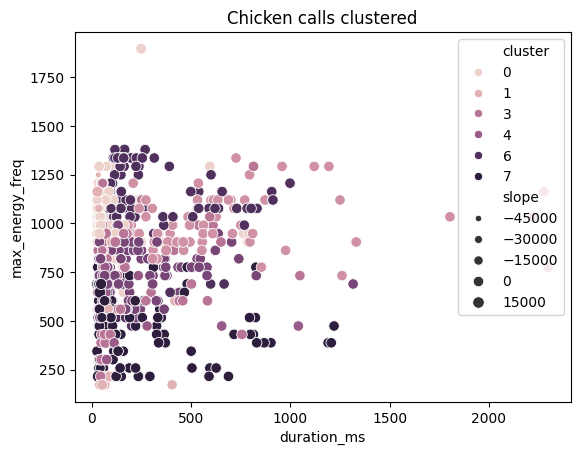

In [34]:
# Scatterplot using hue to highlight cluster with duration on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='duration_ms',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

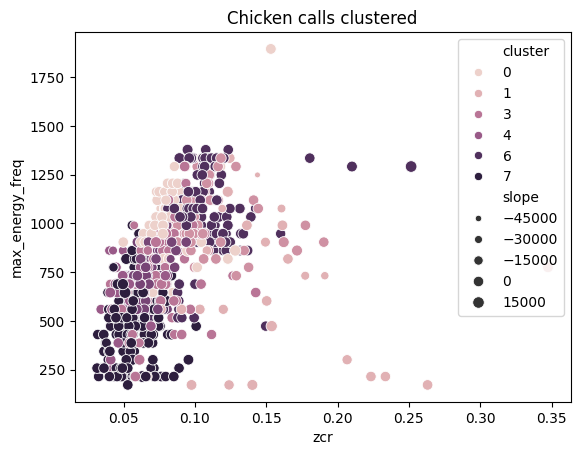

In [35]:
# Scatterplot using hue to highlight cluster with zero-crossing rate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='zcr',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

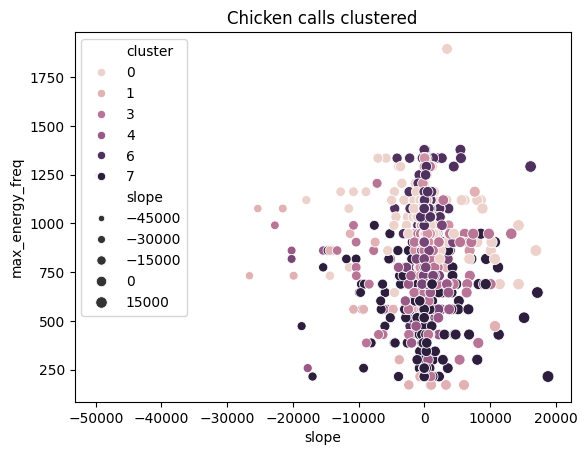

In [36]:
# Scatterplot using hue to highlight cluster with slope estimate on the x-axis and max_energy_freq on the y-axis 
sns.scatterplot(
    data=df,
    x='slope',
    y='max_energy_freq',
    hue='cluster',
    size='slope',
    # palette='tab10',
    # sizes=(20, 200),       # adjust dot size range
    # alpha=0.8
)

plt.title("Chicken calls clustered")
plt.show()

In [63]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "duration_ms", round = 1)

         duration_ms_mean  duration_ms_std
cluster                                   
0                    88.9            139.6
1                    90.3            107.0
4                   116.6            198.1
7                   150.4            220.0
3                   193.2            258.3
5                   241.4            209.5
6                   250.9            225.4
2                   629.0            479.9


Cluster 2 has the longest calls, which are more than twice as long in duration than other calls

In [64]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "max_energy_freq")

         max_energy_freq_mean  max_energy_freq_std
cluster                                           
7                     550.757              195.556
4                     592.796              156.561
1                     660.847              359.266
3                     769.812              208.106
5                     771.315              124.487
2                     999.890              134.752
0                    1017.711              158.521
6                    1058.796              207.100


In [62]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "time_to_next_call_ms", round = 1)

         time_to_next_call_ms_mean  time_to_next_call_ms_std
cluster                                                     
7                            135.3                     169.1
6                            196.8                     219.8
3                            205.6                     334.6
5                            208.8                     382.0
0                            258.8                     433.7
1                            291.0                     468.1
4                            308.2                     145.5
2                           1180.1                    1673.9


Spacing between calls varies, with cluster 2 having the longest silences following the call but also a huge standard deviation

In [57]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "zcr", round = 3)

         zcr_mean  zcr_std
cluster                   
4           0.048    0.009
7           0.059    0.013
5           0.069    0.009
3           0.077    0.018
0           0.083    0.013
2           0.105    0.024
6           0.108    0.022
1           0.148    0.063


Clusters 1 has a very high ZCR, while cluster 4 has a very low ZCR

Cluster 7 is the lowest frequency while cluster 6 is the highest

In [65]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "spectral_bandwidth")

         spectral_bandwidth_mean  spectral_bandwidth_std
cluster                                                 
4                       1208.635                 290.749
2                       1569.181                 275.360
5                       1604.112                 284.122
0                       1749.815                 297.876
7                       1766.511                 331.203
3                       1808.535                 318.395
6                       1815.935                 291.869
1                       2738.043                 295.471


In [66]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "freq_change")

         freq_change_mean  freq_change_std
cluster                                   
5                 143.167          142.736
0                 177.763          203.102
7                 190.289          194.364
4                 236.865          196.713
6                 258.398          383.505
2                 280.868          444.355
3                 337.952          272.247
1                 494.521          453.239


In [67]:
print_mean_and_std_by_group(df = df, groupby = "cluster", variable = "slope")

         slope_mean  slope_std
cluster                       
1         -5879.019  12766.657
4         -2232.285   6264.375
3          -227.942   5780.938
7          -154.219   4539.978
0           219.294   4779.975
2           393.655   1534.837
5           491.847   2399.822
6           594.579   2031.611


These slopes have very high standard deviations, so it's hard to say if there's any trends here

Summary: Adults show 7 call clusters
0 includes very short calls (89 ms) of a higher frequency (1018 Hz) with medium spectral bandwidth and ZCR

1 includes also very short calls (90 ms) with a lower frequency (661 Hz), much higher ZCR and largest spectral bandwidth and frequency change over the course of the call, as well as a lot of slope variability

2 includes very long calls (629 ms) which vary a lot in length and tend to be followed by long silences. They are relatively high frequency (1000 Hz), have a narrower spectral bandwidth, and relatively high ZCR, and over the course of the call the frequency may change quite a bit.

3 includes medium-length calls (193 ms) of medium frequency (770 Hz) and medium ZCR and medium spectral bandwidth. The frequency may change a lot over the course of the call. 

4 includes shorter calls (117 ms) that are relatively low frequency (593 Hz) with the lowest spectral bandwidth and low ZCR.

5 includes medium-length calls (241 ms) that are medium frequency (771 Hz) with medium ZCR and spectral bandwidth and vary the least in frequency over the course of the call. 

6 includes relatively long calls (251 ms) that are the highest frequency (1059 Hz) with high spectral bandwidth with high ZCR and may be made in quick succession 

7 includes medium-length calls (150 ms) that are low frequency (551 Hz) with medium spectral bandwidth, that may be made in quick succession and have low ZCR


In [68]:
# Export results to csv
df.to_csv(f"../../data/output/chickens/{date.today()}_cluster_adult_analysis_output.csv", header=True, index=False)